In [20]:
import pandas as pd
from scipy import stats
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import scipy as sp
from sklearn.gaussian_process.kernels import DotProduct,Matern, WhiteKernel, ExpSineSquared
from sklearn.model_selection import train_test_split
from matplotlib.patches import Polygon
import re
import random
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.ensemble import GradientBoostingRegressor

In [21]:
def plotout(regr,X_test,y_test,Title):
    predicty=regr.predict(X_test)
    feature_importance = regr.feature_importances_
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + 0.5
    fig = plt.figure(figsize=(5, 5))
    plt.barh(pos, feature_importance[sorted_idx], align="center")
    plt.yticks(pos, np.array(x.columns)[sorted_idx])
    plt.title(Title+ " Feature Importance")
    t=pd.DataFrame({'x':np.array(x.columns)[sorted_idx],'b':feature_importance[sorted_idx]})
    t.loc[t["b"]>0.01]["x"].values
    plt.axvline(0.01,c="red")
    RF_testscore = regr.score(X_test, y_test)
    plt.savefig("diag/"+Title+ " Feature Importance.png")
    plt.show()
    
    fig = plt.figure(figsize=(5, 5))
    plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")
    plt.xlabel("predicted", fontsize=15)
    plt.ylabel("observed", fontsize=15)
    plt.title(Title+ " Testing Set", fontsize=15)
    plt.axline((min(predicty), min(predicty)), slope=1,label="1:1 line",color="red")
    plt.legend()
    plt.savefig("diag/"+Title+ " Testing Set.png")
   # plt.show()
    featuredf=pd.DataFrame({"Name":np.array(x.columns)[sorted_idx],"Imp":feature_importance[sorted_idx]})
    featuredf=featuredf.sort_values("Imp",ascending=False)
    print(featuredf.sort_values("Imp",ascending=False))
    return(featuredf)
    
def learn(x,y,save,filename):
    scaler =StandardScaler().fit(x)
    x_z=scaler.transform(x)
    X_train, X_test, y_train, y_test = train_test_split(
             x_z, y, test_size=0.30, random_state=44)
    regr = RandomForestRegressor(n_jobs=-1).fit(X_train, y_train)
    RF_trainscore = regr.score(X_train, y_train)
    print("Training set score_ "+str(RF_trainscore))
    RF_testscore = regr.score(X_test, y_test)
    print("Test set score_ "+str(RF_testscore))
    if save==True: 
        joblib.dump(regr, "data/Models/"+filename+".joblib") 
        joblib.dump(scaler, "data/Models/"+filename+ "_Scalar.joblib") 
    return(X_train, X_test, y_train, y_test,regr)

GPP
Training set score_ 0.9992117121651173
Test set score_ 0.9943875823644824


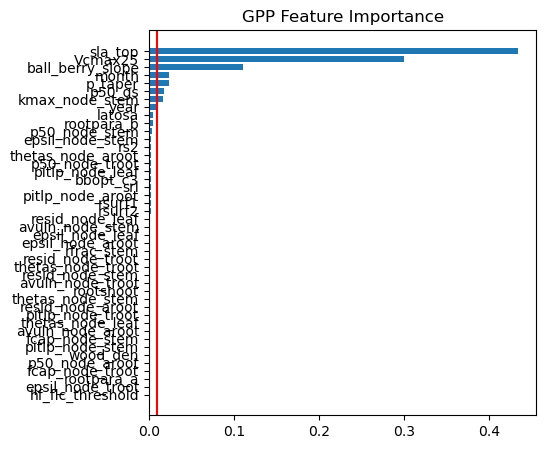

C:\Users\345578\AppData\Local\Temp\ipykernel_14096\461671328.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


                 Name       Imp
43            sla_top  0.434137
42            Vcmax25  0.299571
41   ball_berry_slope  0.110298
40              month  0.023428
39            p_taper  0.023425
38             p50_gs  0.018085
37     kmax_node_stem  0.016318
36               year  0.010718
35             latosa  0.005208
34         rootpara_b  0.005163
33      p50_node_stem  0.003059
32    epsil_node_stem  0.002725
31                rs2  0.002465
30  thetas_node_aroot  0.002344
29     p50_node_troot  0.002272
28    pitlp_node_leaf  0.002247
27           bbopt_c3  0.002219
26                srl  0.002209
25   pitlp_node_aroot  0.002197
24             rsurf1  0.002019
23             rsurf2  0.001990
22    resid_node_leaf  0.001731
21    avuln_node_stem  0.001665
20    epsil_node_leaf  0.001646
19   epsil_node_aroot  0.001626
18         rfrac_stem  0.001511
17   resid_node_troot  0.001467
16  thetas_node_troot  0.001386
15    resid_node_stem  0.001375
14   avuln_node_troot  0.001352
13      

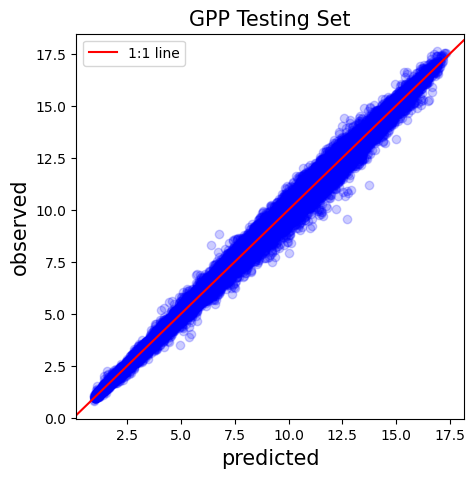

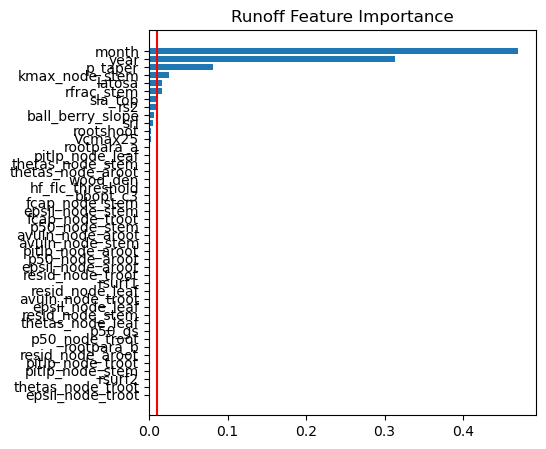

C:\Users\345578\AppData\Local\Temp\ipykernel_14096\461671328.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


                 Name       Imp
43              month  0.469864
42               year  0.313258
41            p_taper  0.081418
40     kmax_node_stem  0.025464
39             latosa  0.016601
38         rfrac_stem  0.016116
37            sla_top  0.011792
36                rs2  0.011538
35   ball_berry_slope  0.006218
34                srl  0.004776
33          rootshoot  0.003095
32            Vcmax25  0.002788
31         rootpara_a  0.001441
30    pitlp_node_leaf  0.001318
29   thetas_node_stem  0.001249
28  thetas_node_aroot  0.001243
27           wood_den  0.001203
26   hf_flc_threshold  0.001197
25           bbopt_c3  0.001197
24     fcap_node_stem  0.001171
23    epsil_node_stem  0.001169
22    fcap_node_troot  0.001166
21      p50_node_stem  0.001164
20   avuln_node_aroot  0.001159
19    avuln_node_stem  0.001152
18   pitlp_node_aroot  0.001150
17     p50_node_aroot  0.001149
16   epsil_node_aroot  0.001145
15   resid_node_troot  0.001145
14             rsurf1  0.001145
13    re

In [ ]:
Variables=pd.read_csv("C:/Users/345578/Documents/GitHub/CRAFT/Emulator_Fitting_Settings1.csv")
SaveName="CRAFT_practice_Full"
thres=.10
EmulatorDirve="C:/Users/345578/Documents/GitHub/CRAFT/data/FATES_outputs/"
FATES_samples=pd.read_csv('C:/Users/345578/Documents/GitHub/CRAFT/data/ML_Transfer/LHS.sam.csv')
Downsample=1.0
### This is the csv you load in: 
ImportanceDF=pd.DataFrame({})
for i in list(range(0,len(Variables["xs"]))):
    xs=Variables.loc[i,"xs"]
    xe=Variables.loc[i,"xe"]
    y_i=Variables.loc[i,"y_i"]
    var_name=Variables.loc[i,"var_name"]
    Scaler=Variables.loc[i,"Scaler"]
    GPP=pd.read_csv(EmulatorDirve+Variables.loc[i, 'FATESruns'])

    
    
    if var_name in ["LWP_max"]:
        GPP["DOY"]=pd.DatetimeIndex(GPP['Date']).dayofyear
        GPP["Year"]=pd.DatetimeIndex(GPP['Date']).year
    x=GPP.iloc[:,np.r_[xs:xe]] ###here skipping all but the first tminus
    y=GPP.iloc[:,y_i]*Scaler
    print(var_name)
    X_train, X_test, y_train, y_test,regr=learn(x,y,True,SaveName+var_name)
    featuredf=plotout(regr,X_test,y_test,var_name)
    row=pd.DataFrame({'Predicting':var_name,
                   'Variable':featuredf.loc[featuredf["Imp"]>thres]["Name"].values,
                   "Importance":featuredf.loc[featuredf["Imp"]>thres]["Imp"].values})
    ImportanceDF=pd.concat([ImportanceDF,row])
ImportanceDF.to_csv("diag/Full_Importance.csv")


GPP
Training set score_ 0.9626514909409486
Test set score_ 0.9616179211486696


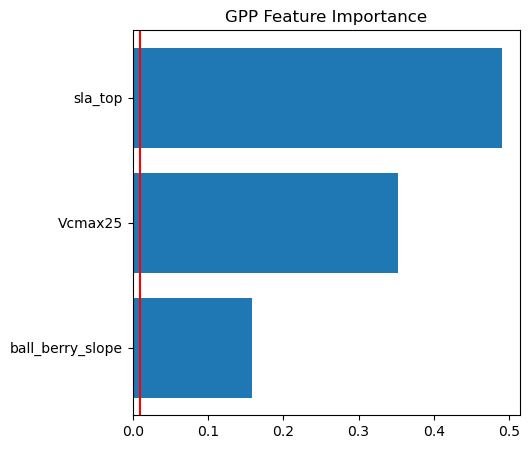

C:\Users\345578\AppData\Local\Temp\ipykernel_14096\127110662.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


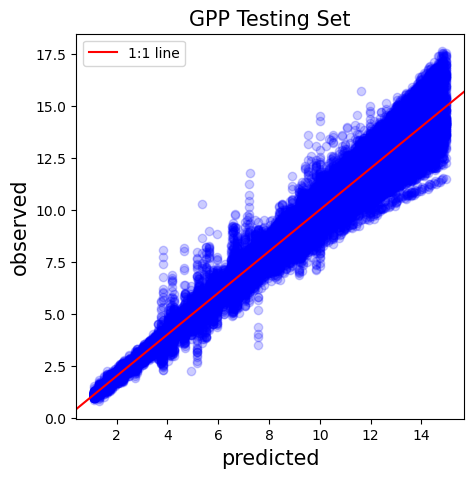

               Name       Imp
2           sla_top  0.490256
1           Vcmax25  0.351883
0  ball_berry_slope  0.157861
GPP
Training set score_ 0.9626513785956811
Test set score_ 0.9616146115096765


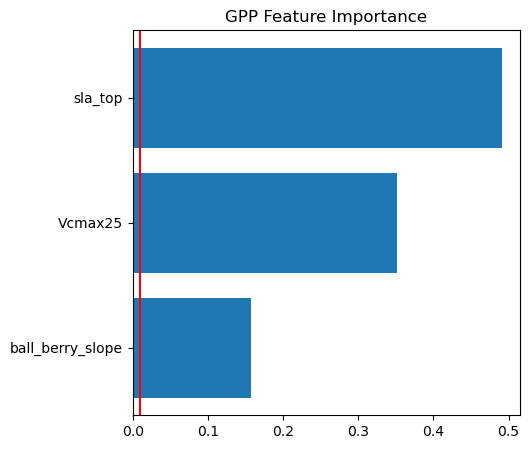

C:\Users\345578\AppData\Local\Temp\ipykernel_14096\127110662.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


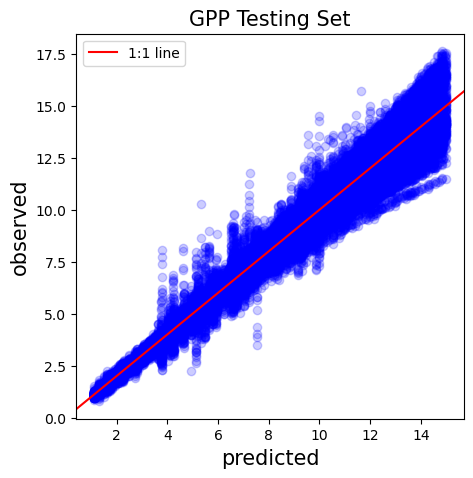

               Name       Imp
2           sla_top  0.490888
1           Vcmax25  0.351321
0  ball_berry_slope  0.157791
Runoff
Training set score_ 0.11150522693156806
Test set score_ 0.09485634299089862


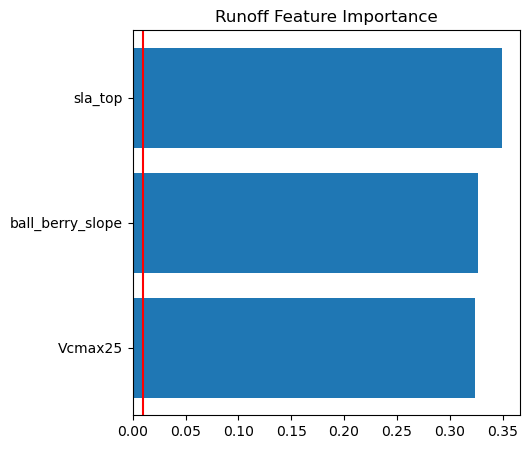

C:\Users\345578\AppData\Local\Temp\ipykernel_14096\127110662.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


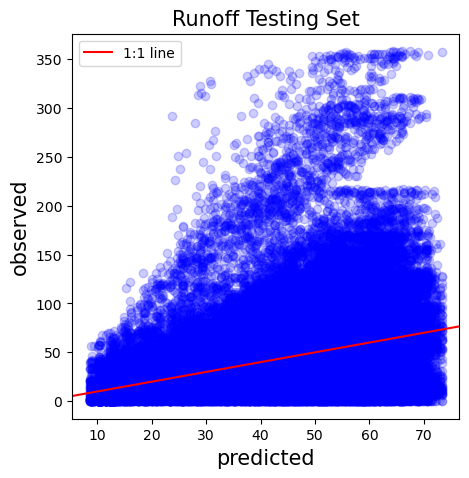

               Name       Imp
2           sla_top  0.349275
1  ball_berry_slope  0.326741
0           Vcmax25  0.323984
H201
Training set score_ 0.1343991929319922
Test set score_ 0.11963609277939902


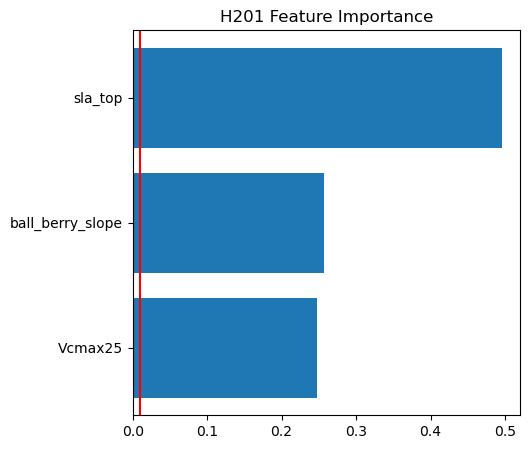

C:\Users\345578\AppData\Local\Temp\ipykernel_14096\127110662.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


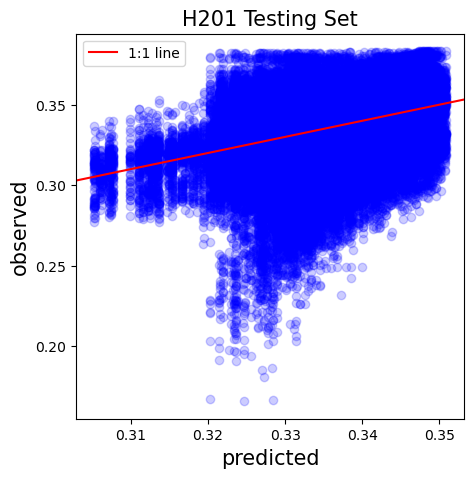

               Name       Imp
2           sla_top  0.495728
1  ball_berry_slope  0.256356
0           Vcmax25  0.247916
ET
Training set score_ 0.5966468981153309
Test set score_ 0.589823026359799


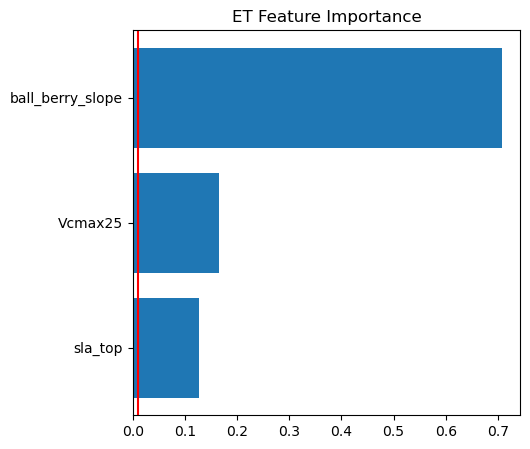

C:\Users\345578\AppData\Local\Temp\ipykernel_14096\127110662.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(predicty,y_test,'ro',alpha=0.2,color="blue")


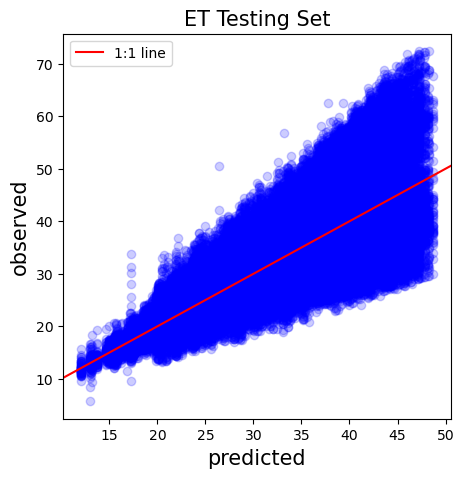

               Name       Imp
2  ball_berry_slope  0.707327
1           Vcmax25  0.165228
0           sla_top  0.127445


In [19]:
NewVars=ImportanceDF["Variable"].unique()
ImportanceDF=pd.DataFrame({})
for i in list(range(0,len(Variables["xs"]))):
    xs=Variables.loc[i,"xs"]
    xe=Variables.loc[i,"xe"]
    y_i=Variables.loc[i,"y_i"]
    var_name=Variables.loc[i,"var_name"]
    Scaler=Variables.loc[i,"Scaler"]
    GPP=pd.read_csv(EmulatorDirve+Variables.loc[i, 'FATESruns'])
    if var_name in ["LWP_max"]:
        GPP["DOY"]=pd.DatetimeIndex(GPP['Date']).dayofyear
        GPP["Year"]=pd.DatetimeIndex(GPP['Date']).year
    x=GPP[NewVars] ###here skipping all but the first tminus
    y=GPP.iloc[:,y_i]*Scaler
    print(var_name)
    X_train, X_test, y_train, y_test,regr=learn(x,y,True,SaveName+var_name)
    featuredf=plotout(regr,X_test,y_test,var_name)
    row=pd.DataFrame({'Predicting':var_name,
                   'Variable':featuredf["Name"].values,
                   "Importance":featuredf["Imp"].values})
    ImportanceDF=pd.concat([ImportanceDF,row])
ImportanceDF.to_csv("diag/Reduced_Importance.csv")